In [ ]:
from utils import load_data

train_path = "train.csv"
val_path = "validation.csv"

train_data = load_data(train_path)
val_data = load_data(val_path)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(9)


[ WARN:0@4.149] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(5)


In [3]:
import urllib.request
import ssl
import certifi

url = "https://download.pytorch.org/models/resnet18-f37072fd.pth"
ctx = ssl.create_default_context(cafile=certifi.where())

req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"} 
)

with urllib.request.urlopen(req, context=ctx) as response:
    data = response.read()
    with open("resnet18-f37072fd.pth", "wb") as f:
        f.write(data)

print("Downloaded weights!")

Downloaded weights!


In [4]:
import torchvision.models as models
import torch

state_dict = torch.load("resnet18-f37072fd.pth")
model = models.resnet18()
model.load_state_dict(state_dict)

model.fc = torch.nn.Linear(model.fc.in_features, 10) # 10 classes
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # can be None or tensor of class weights

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        return focal_loss.mean()

In [6]:
import torch
import torch.optim as optim
import params

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=params.lr)

In [ ]:
outfile = open("results.txt", 'a')
outfile.write("----------------------------\n")
outfile.write("Ablation for task 1.2\n")
outfile.write("---------------------\n")

In [7]:
import time
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from torchvision.models import resnet18
import torch.nn as nn
import numpy as np

gamma_results = []
gamma_values = [1,2,3]

for gamma in gamma_values:
  criterion = FocalLoss(gamma=gamma)
  outfile.write(f"Training with gamma: {gamma}\n")

  model = models.resnet18(weights=None)
  model.fc = nn.Linear(model.fc.in_features, 10)
  model.load_state_dict(torch.load("resnet18-f37072fd.pth"))
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

  best_auc = 0
  best_model_state = None
  

  for epoch in range(3): # shorter run to judge trends
    start = time.time()
    model.train()

    outfile.write(f"Running epoch: {epoch+1}\n")

    for images, labels in train_data:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

    model.eval()
    all_labels = []
    all_probs = []

    outfile.write(f"  Evaluations for the epoch\n")

    with torch.no_grad():
      for images, labels in val_data:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    y_true = label_binarize(all_labels, classes=list(range(10)))

    auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')

    outfile.write(f"Epoch {epoch+1} done, Val AUC: {auc:.4f}\n")
    outfile.write(f"Time taken: {time.time()-start:.2f}s\n")

    if auc > best_auc:
      best_auc = auc
      best_model_state = model.state_dict()

    gamma_results.append(best_auc)

Training with gamma: 1
Running epoch: 1
  Evaluations for the epoch
Epoch 1 done, Val AUC: 0.9996
Time taken: 119.43s
Running epoch: 2
  Evaluations for the epoch
Epoch 2 done, Val AUC: 0.9995
Time taken: 121.06s
Running epoch: 3
  Evaluations for the epoch
Epoch 3 done, Val AUC: 0.9995
Time taken: 129.26s
Training with gamma: 2
Running epoch: 1
  Evaluations for the epoch
Epoch 1 done, Val AUC: 0.9995
Time taken: 121.85s
Running epoch: 2
  Evaluations for the epoch
Epoch 2 done, Val AUC: 0.9992
Time taken: 121.09s
Running epoch: 3
  Evaluations for the epoch
Epoch 3 done, Val AUC: 0.9997
Time taken: 122.24s
Training with gamma: 3
Running epoch: 1
  Evaluations for the epoch
Epoch 1 done, Val AUC: 0.9996
Time taken: 121.24s
Running epoch: 2
  Evaluations for the epoch
Epoch 2 done, Val AUC: 0.9994
Time taken: 122.96s
Running epoch: 3
  Evaluations for the epoch
Epoch 3 done, Val AUC: 0.9995
Time taken: 120.61s


In [ ]:
outfile.close()

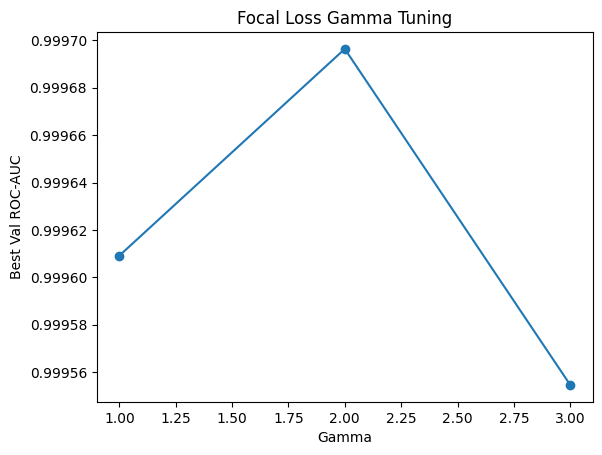

In [11]:
import matplotlib.pyplot as plt

gamma_results = gamma_results[2::3]
plt.plot(gamma_values, gamma_results, marker='o')
plt.xlabel("Gamma")
plt.ylabel("Best Val ROC-AUC")
plt.title("Focal Loss Gamma Tuning")
plt.show()
plt.savefig("Ablation_plot11")

In [ ]:
with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Ablation training results for 1.1\n")
    f.write("------------------------------\n")
    f.write("Values of ROC-AUC across changing gamma:\n")
    for gr in gamma_results:
        f.write(f"{gr}\n")

In [ ]:
from utils import load_data

test_path = "test.csv"

test_data = load_data(test_path)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(best_model_state)
model.eval()

In [ ]:
all_preds = []
all_labels = []
all_probs = []

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
with torch.no_grad():
  for images, labels in test_data:
    images = images.to(device)
    outputs = model(images)

    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    all_probs.append(probs.cpu().numpy())
    all_preds.append(preds.cpu().numpy())
    all_labels.append(labels.numpy())

import numpy as np
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize

y_true = label_binarize(all_labels, classes=list(range(10)))
auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')

acc = accuracy_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds, average='macro')

print("Accuracy: ", acc)
print("F1 Score: ", f1)
print("Macro ROC-AUC: ", auc)

with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Ablation Test results for 1.1\n")
    f.write("------------------------------\n")
    f.write(f"Accuracy: {acc}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"Macro ROC-AUC: {auc}\n")
